In [1]:
import pandas as pd
import numpy as np
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("suicide-watch/suicide_watch_backup.csv")
print(f"Dataset shape: {df.shape}")
print(df.head())

Dataset shape: (232074, 5)
                                          clean_text  label  length  \
0  ex wife threatening suiciderecently i left my ...      1     715   
1  am i weird i dont get affected by compliments ...      0     138   
2  finally is almost over so i can never hear has...      0     129   
3          i need helpjust help me im crying so hard      1      41   
4  im so losthello my name is adam and ive been s...      1    2426   

   risk_score  pronoun_count  
0           1              9  
1           0              4  
2           0              2  
3           0              1  
4           2             13  


In [3]:
analyzer = SentimentIntensityAnalyzer()

def get_vader_scores(text):
    if pd.isna(text) or text == '':
        return 0, 0, 0, 0
    scores = analyzer.polarity_scores(str(text))
    return scores['neg'], scores['neu'], scores['pos'], scores['compound']

print("VADER analyzer initialized!")

VADER analyzer initialized!


In [4]:
print("Processing sentiment scores...")
df[['vader_neg', 'vader_neu', 'vader_pos', 'vader_compound']] = df['clean_text'].apply(
    lambda x: pd.Series(get_vader_scores(x))
)
print("VADER sentiment scores added!")

Processing sentiment scores...
VADER sentiment scores added!


In [5]:
def get_textblob_scores(text):
    if pd.isna(text) or text == '':
        return 0, 0
    blob = TextBlob(str(text))
    return blob.sentiment.polarity, blob.sentiment.subjectivity

print("Processing TextBlob scores...")
df[['tb_polarity', 'tb_subjectivity']] = df['clean_text'].apply(
    lambda x: pd.Series(get_textblob_scores(x))
)
print("TextBlob sentiment scores added!")

Processing TextBlob scores...
TextBlob sentiment scores added!


In [6]:
def sentiment_category(compound):
    if compound >= 0.05:
        return 'positive'
    elif compound <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['sentiment'] = df['vader_compound'].apply(sentiment_category)
print(df['sentiment'].value_counts())

sentiment
negative    128347
positive     86959
neutral      16768
Name: count, dtype: int64


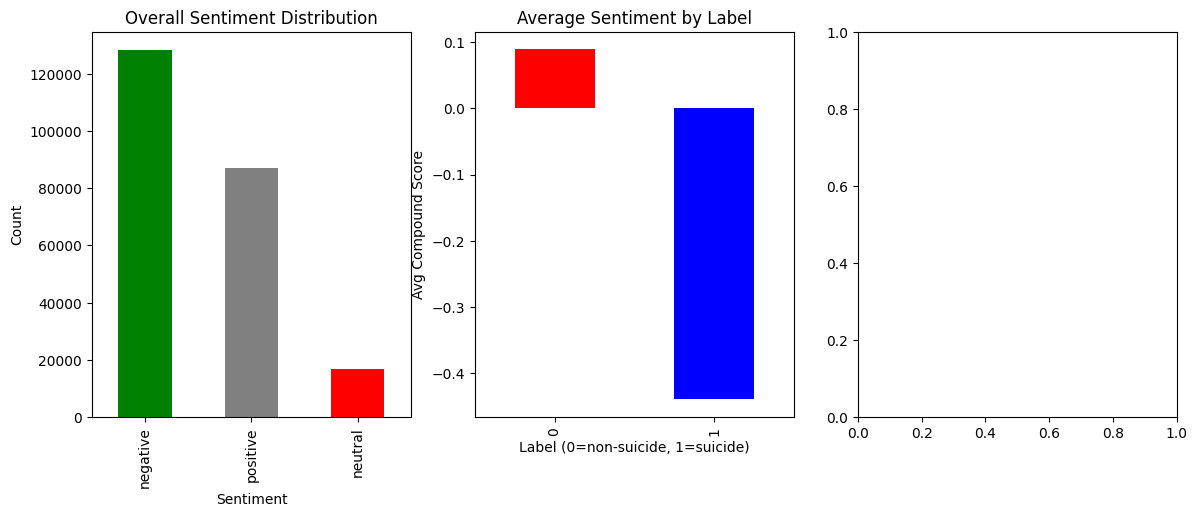

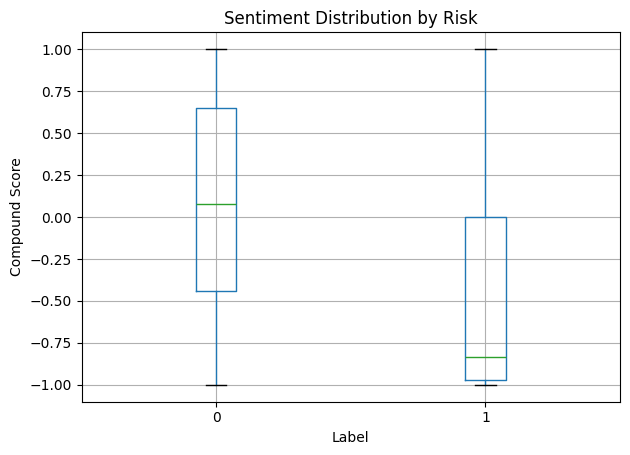

In [7]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
df['sentiment'].value_counts().plot(kind='bar', color=['green', 'gray', 'red'])
plt.title('Overall Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')

plt.subplot(1, 3, 2)
df.groupby('label')['vader_compound'].mean().plot(kind='bar', color=['red', 'blue'])
plt.title('Average Sentiment by Label')
plt.xlabel('Label (0=non-suicide, 1=suicide)')
plt.ylabel('Avg Compound Score')

plt.subplot(1, 3, 3)
df.boxplot(column='vader_compound', by='label')
plt.title('Sentiment Distribution by Risk')
plt.suptitle('')
plt.xlabel('Label')
plt.ylabel('Compound Score')

plt.tight_layout()
plt.savefig('sentiment_analysis.png', dpi=150)
plt.show()

In [8]:
print("\n=== SENTIMENT ANALYSIS SUMMARY ===")
print(f"\nSuicide Posts (label=1):")
print(f"  - Mean Compound: {df[df['label']==1]['vader_compound'].mean():.3f}")
print(f"  - Mean Polarity (TB): {df[df['label']==1]['tb_polarity'].mean():.3f}")
print(f"  - Negative %: {(df[df['label']==1]['sentiment']=='negative').mean()*100:.1f}%")

print(f"\nNon-Suicide Posts (label=0):")
print(f"  - Mean Compound: {df[df['label']==0]['vader_compound'].mean():.3f}")
print(f"  - Mean Polarity (TB): {df[df['label']==0]['tb_polarity'].mean():.3f}")
print(f"  - Positive %: {(df[df['label']==0]['sentiment']=='positive').mean()*100:.1f}%")


=== SENTIMENT ANALYSIS SUMMARY ===

Suicide Posts (label=1):
  - Mean Compound: -0.440
  - Mean Polarity (TB): -0.011
  - Negative %: 73.0%

Non-Suicide Posts (label=0):
  - Mean Compound: 0.089
  - Mean Polarity (TB): 0.037
  - Positive %: 50.6%


In [9]:
df.to_csv("suicide-watch/suicide_watch_with_sentiment.csv", index=False)
print("Dataset with sentiment features saved to: suicide-watch/suicide_watch_with_sentiment.csv")

Dataset with sentiment features saved to: suicide-watch/suicide_watch_with_sentiment.csv


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

features = ['vader_neg', 'vader_neu', 'vader_pos', 'vader_compound', 
            'tb_polarity', 'tb_subjectivity', 'length']

X = df[features].fillna(0)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
print("=== SENTIMENT-BASED CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

=== SENTIMENT-BASED CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.78      0.81      0.79     23287
           1       0.80      0.77      0.78     23128

    accuracy                           0.79     46415
   macro avg       0.79      0.79      0.79     46415
weighted avg       0.79      0.79      0.79     46415



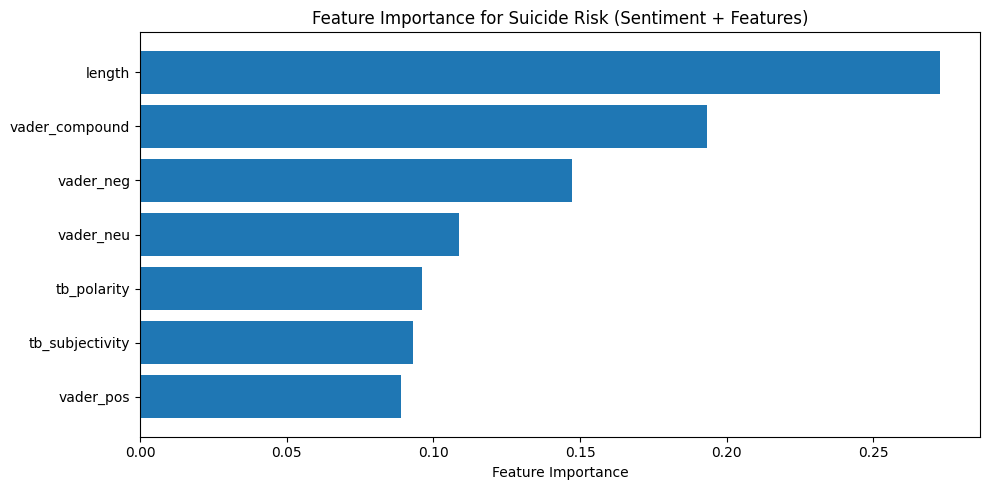

: 

In [ ]:
importances = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(importances['feature'], importances['importance'])
plt.xlabel('Feature Importance')
plt.title('Feature Importance for Suicide Risk (Sentiment + Features)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()